In [ ]:
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [ ]:
# ============================================
# 3. BASIC DATASET INFORMATION
# ============================================

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== LAST 5 ROWS ==========")
print(df.tail())

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== DATASET INFO ==========")
df.info()



========== DATASET SHAPE ==========
(1347680, 12)

========== FIRST 5 ROWS ==========
      issue_d    revenue  dti_n  loan_amnt  fico_n  new_borrower  emp_length  \
0  2015-12-01  55,000.00   5.91       3600  677.00             1       10.00   
1  2015-12-01  65,000.00  16.06      24700  717.00             1       10.00   
2  2015-12-01  71,000.00  13.85      20000  697.00             1       10.00   
3  2015-12-01 104,433.00  25.37      10400  697.00             1        3.00   
4  2015-12-01  34,000.00  10.20      11950  692.00             1        4.00   

              purpose home_ownership_n addr_state zip_code  Default  
0  debt_consolidation         MORTGAGE         PA    190xx        0  
1      small_business         MORTGAGE         SD    577xx        0  
2    home_improvement         MORTGAGE         IL    605xx        0  
3      major_purchase         MORTGAGE         PA    174xx        0  
4  debt_consolidation             RENT         GA    300xx        0  

========== 

In [ ]:
df['issue_d']=pd.to_datetime(df['issue_d'])


In [ ]:
# ============================================
# 4. STATISTICAL SUMMARY
# ============================================

print("\n========== NUMERICAL SUMMARY ==========")
print(df.describe())

print("\n========== CATEGORICAL SUMMARY ==========")
print(df.describe(include="object"))


========== NUMERICAL SUMMARY ==========
                             issue_d       revenue        dti_n    loan_amnt  \
count                        1347680  1,347,680.00 1,347,680.00 1,347,680.00   
mean   2015-06-01 22:04:40.011872512     77,369.71        18.30    14,408.24   
min              2007-06-01 00:00:00      1,896.00         0.00       500.00   
25%              2014-07-01 00:00:00     46,600.00        11.82     7,975.00   
50%              2015-08-01 00:00:00     65,000.00        17.63    12,000.00   
75%              2016-07-01 00:00:00     92,000.00        24.07    20,000.00   
max              2018-12-01 00:00:00 10,999,200.00       999.00    40,000.00   
std                              NaN     70,363.01        11.15     8,715.35   

            fico_n  new_borrower   emp_length      Default  
count 1,347,680.00  1,347,680.00 1,347,680.00 1,347,680.00  
mean        698.16          1.00         5.62         0.20  
min         612.00          0.00         0.00         0

In [ ]:

# ============================================
# 5. MISSING VALUES
# ============================================

print("\n========== MISSING VALUES ==========")

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing_Count",
    ascending=False
)
print(missing)



========== MISSING VALUES ==========
                  Missing_Count  Missing_Percentage
issue_d                       0                0.00
revenue                       0                0.00
dti_n                         0                0.00
loan_amnt                     0                0.00
fico_n                        0                0.00
new_borrower                  0                0.00
emp_length                    0                0.00
purpose                       0                0.00
home_ownership_n              0                0.00
addr_state                    0                0.00
zip_code                      0                0.00
Default                       0                0.00


In [ ]:
df.dropna(inplace=True)

In [ ]:
# ============================================
# 6. DUPLICATE ROWS
# ============================================

print("\n========== DUPLICATES ==========")

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)


========== DUPLICATES ==========
Duplicate rows: 0


In [ ]:

# ============================================
# 7. UNIQUE VALUES
# ============================================

print("\n========== UNIQUE VALUES ==========")

unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique() for col in df.columns]
})

print(unique_values)


========== UNIQUE VALUES ==========
              Column  Unique_Values
0            issue_d            139
1            revenue          65608
2              dti_n           7068
3          loan_amnt           1560
4             fico_n             48
5       new_borrower              2
6         emp_length             11
7            purpose             14
8   home_ownership_n              4
9         addr_state             51
10          zip_code            945
11           Default              2


In [ ]:

# ============================================
# 8. TARGET VARIABLE - DEFAULT
# ============================================

print("\n========== DEFAULT DISTRIBUTION ==========")

print(df["Default"].value_counts())

print("\n========== DEFAULT PERCENTAGE ==========")

default_percentage = (
    df["Default"]
    .value_counts(normalize=True)
    .mul(100)
)
print(default_percentage)




========== DEFAULT DISTRIBUTION ==========
Default
0    1078431
1     269249
Name: count, dtype: int64

========== DEFAULT PERCENTAGE ==========
Default
0   80.02
1   19.98
Name: proportion, dtype: float64


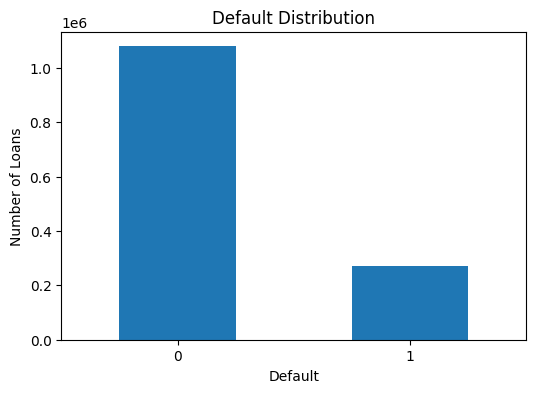

In [ ]:
# ============================================
# 7. DEFAULT VISUALIZATION
# ============================================

df["Default"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Default Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)
plt.show()


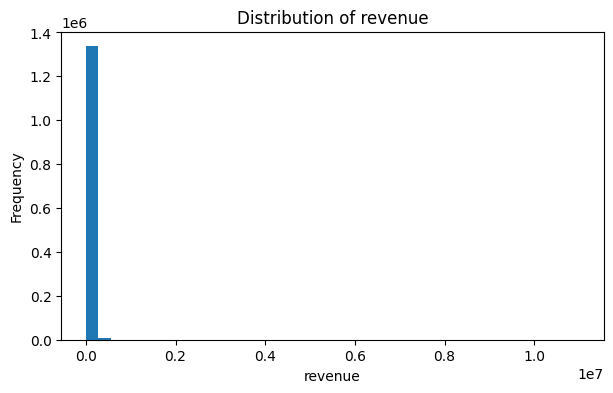

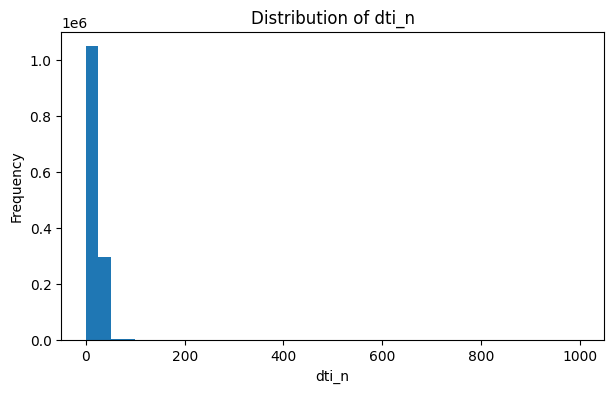

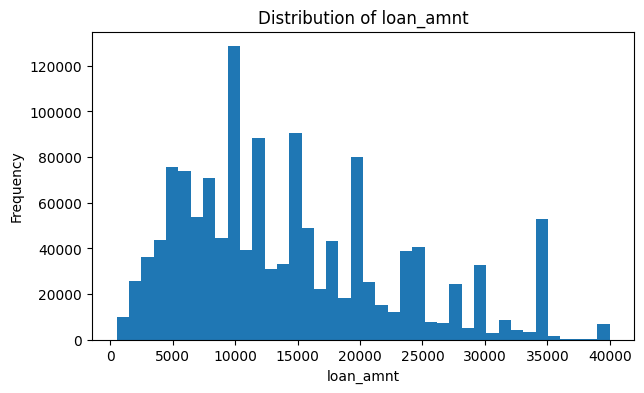

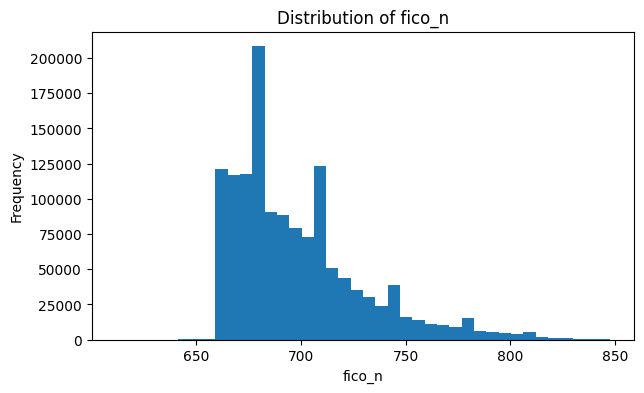

In [ ]:
# ============================================
# 8. NUMERICAL DISTRIBUTIONS
# ============================================

for column in numeric_columns:

    plt.figure(figsize=(7, 4))

    plt.hist(
        df[column].dropna(),
        bins=40
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()


In [ ]:
# ============================================
# 9. DATA VALIDATION
# ============================================

print("\n========== DATA VALIDATION ==========")

print(
    "Negative Revenue:",
    (df["revenue"] < 0).sum()
)

print(
    "Negative DTI:",
    (df["dti_n"] < 0).sum()
)

print(
    "Negative Loan Amount:",
    (df["loan_amnt"] < 0).sum()
)

print(
    "FICO below 300:",
    (df["fico_n"] < 300).sum()
)

print(
    "FICO above 850:",
    (df["fico_n"] > 850).sum()
)



========== DATA VALIDATION ==========
Negative Revenue: 0
Negative DTI: 0
Negative Loan Amount: 0
FICO below 300: 0
FICO above 850: 0


In [ ]:
# ============================================
# 10. DEFAULT BY PURPOSE
# ============================================

purpose_default = (
    df.groupby("purpose")["Default"]
    .agg(["count", "mean"])
)

purpose_default["default_rate"] = (
    purpose_default["mean"] * 100
)

purpose_default = purpose_default.drop(
    columns="mean"
)

print("\n========== DEFAULT BY PURPOSE ==========")

print(
    purpose_default
    .sort_values("default_rate", ascending=False)
)


========== DEFAULT BY PURPOSE ==========
                     count  default_rate
purpose                                 
small_business       15575         29.86
renewable_energy       936         23.72
moving                9520         23.41
house                 7294         21.91
medical              15606         21.84
debt_consolidation  781205         21.15
other                78263         21.08
educational            423         20.80
vacation              9083         19.19
major_purchase       29543         18.60
home_improvement     87684         17.76
credit_card         295551         16.93
car                  14647         14.70
wedding               2350         12.43


In [ ]:
# ============================================
# 11. DEFAULT BY HOME OWNERSHIP
# ============================================

home_default = (
    df.groupby("home_ownership_n")["Default"]
    .agg(["count", "mean"])
)

home_default["default_rate"] = (
    home_default["mean"] * 100
)

home_default = home_default.drop(
    columns="mean"
)

print("\n========== DEFAULT BY HOME OWNERSHIP ==========")

print(
    home_default
    .sort_values("default_rate", ascending=False)
)




========== DEFAULT BY HOME OWNERSHIP ==========
                   count  default_rate
home_ownership_n                      
RENT              535585         23.23
OWN               144985         20.63
OTHER                517         19.73
MORTGAGE          666593         17.23


In [ ]:
# ============================================
# 12. DEFAULT BY EMPLOYMENT LENGTH
# ============================================

employment_default = (
    df.groupby("emp_length")["Default"]
    .agg(["count", "mean"])
)

employment_default["default_rate"] = (
    employment_default["mean"] * 100
)

employment_default = employment_default.drop(
    columns="mean"
)

print("\n========== DEFAULT BY EMPLOYMENT LENGTH ==========")

print(
    employment_default
    .sort_values("default_rate", ascending=False)
)



========== DEFAULT BY EMPLOYMENT LENGTH ==========
             count  default_rate
emp_length                      
0.00        186705         23.23
1.00         88841         20.59
3.00        107862         19.99
8.00         60808         19.95
9.00         51019         19.91
2.00        122091         19.82
4.00         80761         19.76
5.00         84326         19.62
7.00         59724         19.51
6.00         62877         19.38
10.00       442666         18.80


In [ ]:
# ============================================
# 13. FICO CATEGORIES
# ============================================

df["fico_category"] = pd.cut(
    df["fico_n"],
    bins=[0, 579, 669, 739, 799, 850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Exceptional"
    ]
)

fico_default = (
    df.groupby(
        "fico_category",
        observed=True
    )["Default"]
    .agg(["count", "mean"])
)

fico_default["default_rate"] = (
    fico_default["mean"] * 100
)

fico_default = fico_default.drop(
    columns="mean"
)

print("\n========== DEFAULT BY FICO ==========")

print(fico_default)



========== DEFAULT BY FICO ==========
                count  default_rate
fico_category                      
Fair           238506         26.30
Good           963882         19.97
Very Good      129847         10.04
Exceptional     15445          6.41


In [ ]:
# ============================================
# 14. DTI CATEGORIES
# ============================================

df["dti_category"] = pd.cut(
    df["dti_n"],
    bins=[-np.inf, 10, 20, 30, 40, np.inf],
    labels=[
        "0-10",
        "10-20",
        "20-30",
        "30-40",
        "40+"
    ]
)

dti_default = (
    df.groupby(
        "dti_category",
        observed=True
    )["Default"]
    .agg(["count", "mean"])
)

dti_default["default_rate"] = (
    dti_default["mean"] * 100
)

dti_default = dti_default.drop(
    columns="mean"
)

print("\n========== DEFAULT BY DTI ==========")

print(dti_default)


========== DEFAULT BY DTI ==========
               count  default_rate
dti_category                      
0-10          245652         14.84
10-20         563434         17.85
20-30         409867         23.08
30-40         121923         29.13
40+             6804         30.67


In [ ]:
# ============================================
# 15. CORRELATION WITH DEFAULT
# ============================================


# Get a list of all numerical columns from the DataFrame
numeric_cols_for_corr = df.select_dtypes(include=np.number).columns.tolist()

if "Default" not in numeric_cols_for_corr:
    numeric_cols_for_corr.append("Default")

# Create a new DataFrame with only the relevant numerical columns
df_numeric_for_correlation = df[numeric_cols_for_corr]

# Calculate the correlation matrix
correlation = df_numeric_for_correlation.corr()

print("\n========== CORRELATION WITH DEFAULT ==========")

# Print the correlation of all numerical features with 'Default'
# The 'Default' column is now guaranteed to be in the correlation matrix.
print(
    correlation["Default"]
    .sort_values(ascending=False)
)


========== CORRELATION WITH DEFAULT ==========
Default         1.00
dti_n           0.09
loan_amnt       0.07
new_borrower    0.00
emp_length     -0.03
revenue        -0.04
fico_n         -0.13
Name: Default, dtype: float64


In [ ]:
# ============================================
# 16. FICO + DTI RISK ANALYSIS
# ============================================

fico_dti = (
    df.groupby(
        ["fico_category", "dti_category"],
        observed=True
    )["Default"]
    .agg(["count", "mean"])
)

fico_dti["default_rate"] = (
    fico_dti["mean"] * 100
)

fico_dti = fico_dti.drop(
    columns="mean"
)

print("\n========== FICO + DTI ==========")

print(
    fico_dti
    .sort_values("default_rate", ascending=False)
    .head(15)
)


========== FICO + DTI ==========
                             count  default_rate
fico_category dti_category                      
Fair          40+             1065         39.44
              30-40          20976         36.46
              20-30          70607         30.55
Good          40+             5069         30.36
              30-40          92545         28.66
Fair          10-20         101183         24.10
Good          20-30         304477         22.67
Very Good     40+              617         19.61
Fair          0-10           44675         19.49
Good          10-20         402290         17.71
Very Good     30-40           7807         16.57
Good          0-10          159501         15.17
Exceptional   40+               53         13.21
Very Good     20-30          32093         11.81
              0-10           35215          9.04


In [ ]:
# ============================================
# 17. KEY EDA SUMMARY
# ============================================

print("\n============================================")
print("EDA COMPLETE")
print("============================================")

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Default Rate: {df['Default'].mean() * 100:.2f}%")
print(f"Duplicate Rows: {df.duplicated().sum():,}")
print(
    f"Total Missing Values: "
    f"{df.isnull().sum().sum():,}"
)

print("\nImportant variables analyzed:")
print("- FICO")
print("- DTI")
print("- Revenue")
print("- Loan Amount")
print("- Employment Length")
print("- Loan Purpose")
print("- Home Ownership")
print("- Experience")


EDA COMPLETE
Rows: 1,347,680
Columns: 14
Default Rate: 19.98%
Duplicate Rows: 0
Total Missing Values: 0

Important variables analyzed:
- FICO
- DTI
- Revenue
- Loan Amount
- Employment Length
- Loan Purpose
- Home Ownership
- Experience
